# Les relations RCC8

RCC8 decrit les relations topologiques possibles entre deux regions spatiales. Le modele ne manipule pas de coordonnees exactes dans le raisonnement: il manipule des symboles comme `DC`, `EC` ou `TPP`.

Ce notebook presente les huit relations de base et montre comment elles sont representees dans le projet.

In [1]:
from matplotlib import pyplot as plt
from matplotlib.patches import Circle

from rcc8.relations import ALL_RELATIONS, RCC8, inverse_relation, is_symmetric

RELATION_ORDER = ["DC", "EC", "PO", "EQ", "TPP", "NTPP", "TPPI", "NTPPI"]

print("Relations implementees:", RELATION_ORDER)
assert set(RELATION_ORDER) == set(ALL_RELATIONS)

Relations implementees: ['DC', 'EC', 'PO', 'EQ', 'TPP', 'NTPP', 'TPPI', 'NTPPI']


## 1. Signification des huit relations

Chaque relation exprime la position topologique de `A` par rapport a `B`.

In [2]:
descriptions = {
    "DC": "Disconnected: A et B sont separes.",
    "EC": "Externally Connected: A et B se touchent par le bord.",
    "PO": "Partial Overlap: A et B se chevauchent partiellement.",
    "EQ": "Equal: A et B sont la meme region.",
    "TPP": "Tangential Proper Part: A est dans B et touche son bord.",
    "NTPP": "Non-Tangential Proper Part: A est strictement dans B.",
    "TPPI": "Inverse de TPP: B est une partie propre tangentielle de A.",
    "NTPPI": "Inverse de NTPP: B est strictement dans A.",
}

for relation in RELATION_ORDER:
    print(f"{relation:5} -> {descriptions[relation]}")

DC    -> Disconnected: A et B sont separes.
EC    -> Externally Connected: A et B se touchent par le bord.
PO    -> Partial Overlap: A et B se chevauchent partiellement.
EQ    -> Equal: A et B sont la meme region.
TPP   -> Tangential Proper Part: A est dans B et touche son bord.
NTPP  -> Non-Tangential Proper Part: A est strictement dans B.
TPPI  -> Inverse de TPP: B est une partie propre tangentielle de A.
NTPPI -> Inverse de NTPP: B est strictement dans A.


## 2. Relations inverses

Certaines relations sont symetriques: les lire de `A` vers `B` ou de `B` vers `A` ne change rien. D'autres ont une relation inverse.

In [3]:
for relation in RELATION_ORDER:
    inverse = inverse_relation(relation)
    symmetric = "oui" if is_symmetric(relation) else "non"
    print(f"{relation:5} inverse -> {inverse:5} | symetrique: {symmetric}")

assert inverse_relation("TPP") == "TPPI"
assert inverse_relation("NTPP") == "NTPPI"
assert inverse_relation("EC") == "EC"
assert inverse_relation(RCC8.TPP) == RCC8.TPPI

DC    inverse -> DC    | symetrique: oui
EC    inverse -> EC    | symetrique: oui
PO    inverse -> PO    | symetrique: oui
EQ    inverse -> EQ    | symetrique: oui
TPP   inverse -> TPPI  | symetrique: non
NTPP  inverse -> NTPPI | symetrique: non
TPPI  inverse -> TPP   | symetrique: non
NTPPI inverse -> NTPP  | symetrique: non


## 3. Visualisation intuitive

Les dessins ci-dessous utilisent des disques pour donner une intuition geometrique. Le solveur RCC8, lui, ne raisonne pas sur ces coordonnees: il raisonne uniquement sur les relations symboliques.

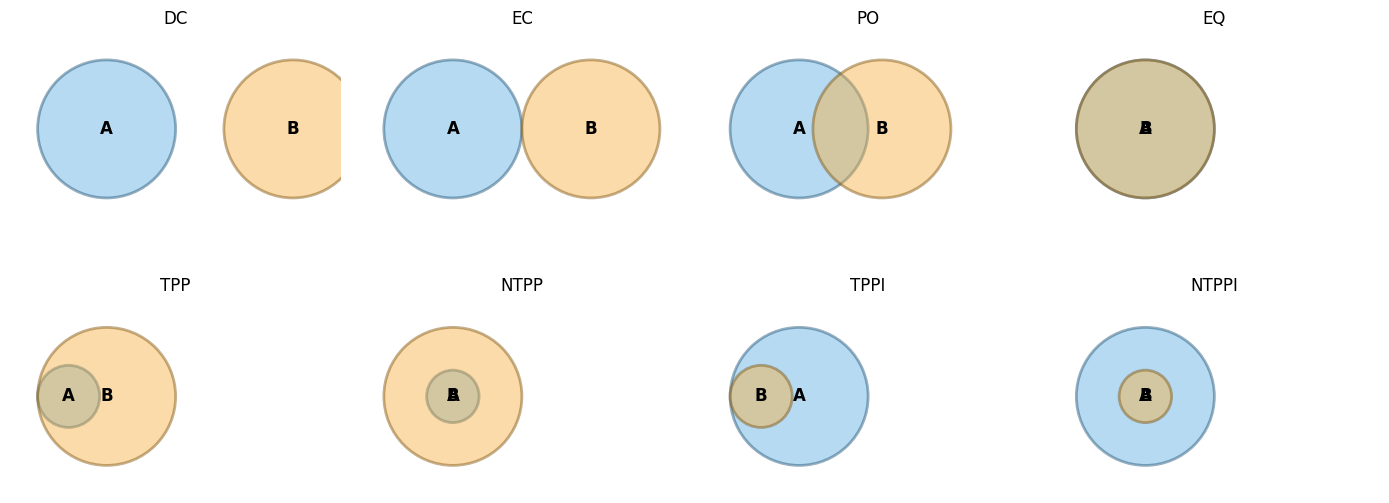

In [4]:
def circle_params(relation):
    """Retourne deux cercles illustrant la relation A vers B."""
    if relation == "DC":
        return (0.0, 0.0, 1.0), (2.7, 0.0, 1.0)
    if relation == "EC":
        return (0.0, 0.0, 1.0), (2.0, 0.0, 1.0)
    if relation == "PO":
        return (0.0, 0.0, 1.0), (1.2, 0.0, 1.0)
    if relation == "EQ":
        return (0.0, 0.0, 1.0), (0.0, 0.0, 1.0)
    if relation == "TPP":
        return (-0.55, 0.0, 0.45), (0.0, 0.0, 1.0)
    if relation == "NTPP":
        return (0.0, 0.0, 0.38), (0.0, 0.0, 1.0)
    if relation == "TPPI":
        return (0.0, 0.0, 1.0), (-0.55, 0.0, 0.45)
    if relation == "NTPPI":
        return (0.0, 0.0, 1.0), (0.0, 0.0, 0.38)
    raise ValueError(relation)


def draw_relation(ax, relation):
    a, b = circle_params(relation)
    ax.add_patch(Circle(a[:2], a[2], facecolor="#5DADE2", edgecolor="#1B4F72", alpha=0.45, linewidth=2))
    ax.add_patch(Circle(b[:2], b[2], facecolor="#F5B041", edgecolor="#7E5109", alpha=0.45, linewidth=2))
    ax.text(a[0], a[1], "A", ha="center", va="center", fontsize=12, weight="bold")
    ax.text(b[0], b[1], "B", ha="center", va="center", fontsize=12, weight="bold")
    ax.set_title(relation)
    ax.set_aspect("equal")
    ax.set_xlim(-1.4, 3.4)
    ax.set_ylim(-1.4, 1.4)
    ax.axis("off")


fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, relation in zip(axes.ravel(), RELATION_ORDER):
    draw_relation(ax, relation)
plt.tight_layout()
plt.show()

## 4. Mini-exemples de lecture

La relation est toujours orientee: `TPP` et `TPPI` ne disent pas la meme chose.

In [5]:
examples = [
    ("Piece", "Batiment", "TPP"),
    ("Robot", "Obstacle", "DC"),
    ("Zone_depart", "Couloir", "EC"),
    ("Zone_scannee", "Zone_interdite", "PO"),
]

for a, b, relation in examples:
    print(f"{a} --{relation}--> {b}")
    print(f"{b} --{inverse_relation(relation)}--> {a}")
    print()

assert inverse_relation("TPP") == "TPPI"

Piece --TPP--> Batiment
Batiment --TPPI--> Piece

Robot --DC--> Obstacle
Obstacle --DC--> Robot

Zone_depart --EC--> Couloir
Couloir --EC--> Zone_depart

Zone_scannee --PO--> Zone_interdite
Zone_interdite --PO--> Zone_scannee



## 5. A RETENIR

- RCC8 contient huit relations de base.
- `DC`, `EC`, `PO` et `EQ` sont symetriques.
- `TPP` et `NTPP` ont des inverses: `TPPI` et `NTPPI`.
- Le solveur manipule des ensembles de relations possibles, pas des coordonnees.